In [6]:
import torch
import sionna

# 检验环境
print(torch.__version__)
print(sionna.__version__)

print("CUDA available: ", torch.cuda.is_available())

if torch.cuda.is_available( ):
    print("GPU device name:", torch.cuda.get_device_name())

2.11.0+cpu
2.0.1
CUDA available:  False


In [7]:
from sionna.phy.channel.tr38901 import UMa, PanelArray

carrier_frequency = 3.5e9  # 载波频率, 单位 Hz

# 创建 UT antenna
ut_array = PanelArray(num_rows_per_panel=1, num_cols_per_panel=1,
                     polarization='single', polarization_type='V',
                     antenna_pattern='omni', carrier_frequency=carrier_frequency)  # 一个天线阵列
# 创建 BS antenna
bs_array = PanelArray(num_rows_per_panel=1, num_cols_per_panel=4,
                      polarization='single', polarization_type='V',
                       antenna_pattern='38.901', carrier_frequency=carrier_frequency)
# 创建一个UMa信道模型
channel_model = UMa(
    carrier_frequency=carrier_frequency,
    o2i_model="low",
    ut_array=ut_array,
    bs_array=bs_array,
    direction="downlink",
    enable_pathloss=True,
    enable_shadow_fading=True,
)

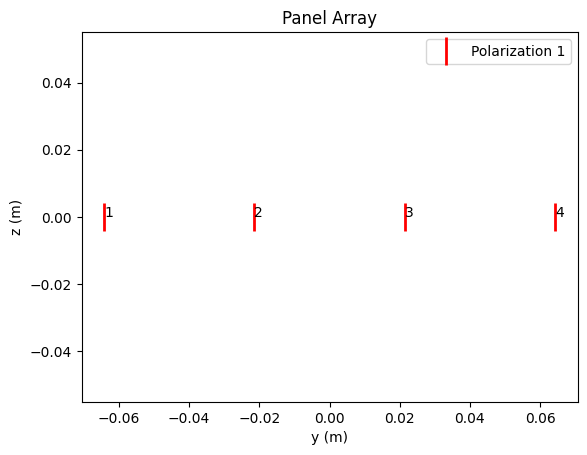

In [8]:
bs_array.show()

In [9]:
# 设置拓扑信息（可以理解为位置信息）
ut_loc = torch.tensor([[[100.0, 0.0, 1.5]]], dtype=torch.float32) # UT位置
bs_loc = torch.tensor([[[0.0, 0.0, 25.0]]], dtype=torch.float32) # BS位置

batch_size, num_ut, num_bs = 1, 1, 1
bs_orientation = torch.zeros((batch_size, num_bs, 3), dtype=torch.float32) # BS的朝向

ut_orientation = torch.zeros((batch_size, num_ut, 3), dtype=torch.float32) # UT的朝向

ut_velocities = torch.zeros((batch_size, num_ut, 3), dtype=torch.float32) # UT的移动速度

in_state = torch.tensor([[False]], dtype=torch.bool) # 室内/室外状态


In [10]:
# 把位置信息、朝向信息、速度信息等传入信道模型中
channel_model.set_topology(
    ut_loc=ut_loc,
    bs_loc=bs_loc,
    ut_orientations=ut_orientation,
    bs_orientations=bs_orientation,
    ut_velocities=ut_velocities,
    in_state=in_state,
    los=False,
)

In [11]:
num_time_samples = 2 # 采样时间点数
sampling_frequency = 1.0  # 采样频率 [Hz]，采样时间间隔 [s]=1/num_time_samples

# a.shape: [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_samples], `torch.complex`. Path coefficients.
#  tau.shape: [batch size, num_rx, num_tx, num_paths], `torch.float`. Path delays [s].
a, tau = channel_model(
    num_time_samples=num_time_samples,
    sampling_frequency=sampling_frequency)

In [12]:
print("\n=== CIR information ===")

print("\na:")
print("type :", type(a))
print("dtype:", a.dtype)
print("shape:", a.shape)
# print("data:", a)

print("\ntau:")
print("type :", type(tau))
print("dtype:", tau.dtype)
print("shape:", tau.shape)
# print("data:", tau)


=== CIR information ===

a:
type : <class 'torch.Tensor'>
dtype: torch.complex64
shape: torch.Size([1, 1, 1, 1, 4, 24, 2])

tau:
type : <class 'torch.Tensor'>
dtype: torch.float32
shape: torch.Size([1, 1, 1, 24])


In [13]:
print("\nNumber of paths:")
print(a.shape[-2])


Number of paths:
24


In [14]:
from sionna.phy.channel import cir_to_ofdm_channel
from sionna.phy.channel import subcarrier_frequencies

In [15]:
fft_size = 64 # 子载波（即频率）的个数
subcarrier_spacing = 30e3  # 子载波间隔 
B=fft_size*subcarrier_spacing  # 总带宽（频率的范围） B=fft_size*subcarrier_spacing Hz
# print("B:", B, "B/2:", B/2, "B/fft_size:", B/fft_size)
#  
frequencies = subcarrier_frequencies(num_subcarriers=fft_size, subcarrier_spacing=subcarrier_spacing)
print("frequencies shape:", frequencies.shape)
# print(frequencies)

frequencies shape: torch.Size([64])


In [16]:
# 把时延域上的信道转换为频域上的信道（即把CIR转换为FIR信道）
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=False) # shape:[batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, fft_size]
print("\n=== Frequency-domain channel ===")
print("dtype:", h_freq.dtype)
print("shape:", h_freq.shape)



=== Frequency-domain channel ===
dtype: torch.complex64
shape: torch.Size([1, 1, 1, 1, 4, 2, 64])
